# ODSB-17086 — Audience Staleness Validation

**Ticket:** [ODSB-17086](https://mlc.atlassian.net/browse/ODSB-17086)  
**Advertiser:** 야놀자 (Yanolja) — `Os7oojpjTo8JwHIt`  
**Campaign:** `cTicyo2cW52zb5t6` (RE-appopen-ios-intrabound-lat)  
**Customer Set:** `tNfrTtz2roqYIWbt` (`RE_LAT_IOS_BETA_Incl_Purchase365_Excl_Open30`)  
**CS seed date:** 2026-03-25 (SQL rendered with this date)  
**Check date:** 2026-03-26 KST (= 2026-03-25 UTC)

---

## Objective

Compute what **% of total targeted IDFA users** had `af_app_opened` events in the last 30 days —
i.e., users who should have been excluded by the `ExcludeOpen30` rule but were not.

**Known baseline (from doc):**
- 1,251 IDFAs total with app_open events in last 30d
  - **959 (76.7%)** — events only on Mar 25–26: explained by 1-day refresh lag (expected behavior)
  - **292 (23.3%)** — genuine violations: opened app before Mar 25, still in target list

**Key question:** `292 / total_targeted_IDFAs` = true stale rate (genuine violations only)

---

## Validation Pipeline (from doc)

```
lat_user_tagging_beta.tagging_full_latest   →  IGv5 (final_cc_release)  →  df_accesslog.pb
  (UPT-tagged mpids for tNfrTtz2roqYIWbt)      (mpid → raw IDFA)           (af_app_opened L30d)
```

---

## Tables

| Table | Role |
|-------|------|
| `moloco-ods.lat_user_tagging_beta.tagging_full_latest` | UPT-tagged mpids for the customer set |
| `moloco-dsp-identity-prod.release_v5_1.final_cc_release` | IGv5: mpid → IDFA mapping (`id LIKE 'i:%'`) |
| `moloco-dsp-data-view.postback.pb` | Postback events — unsampled authorized view (replaces deprecated `focal-elf-631.df_accesslog.pb`) |
| `focal-elf-631.rs.ios_re_closed_beta_summary_table` | LAT RE beta summary — all events incl. organic |

In [46]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

client = bigquery.Client(project='moloco-ods')

def run_query(query, label=''):
    df = client.query(query).result().to_dataframe()
    print(f'✅ {label}: {len(df)} rows')
    return df

# Key parameters
ADVERTISER_ID   = 'Os7oojpjTo8JwHIt'
CAMPAIGN_ID     = 'cTicyo2cW52zb5t6'
CUSTOMER_SET_ID = 'tNfrTtz2roqYIWbt'
APP_BUNDLE      = 'id436731843'
CHECK_DATE      = '2026-04-09'   # Today's date — tagging_full_latest is a current snapshot only, prior states not recoverable
EXCL_WINDOW     = 30             # ExcludeOpen30

# Known baseline from doc validation
TOTAL_WITH_OPEN      = 1251
DAY_OF_LAG           = 959   # Mar 25-26 only — 1-day lag artifact
GENUINE_VIOLATIONS   = 292   # Opened before Mar 25 — true stale

## Section 0 — Original Doc Validation (Replicated as of Today)

Replicates the exact query from the investigation doc (originally run 2026-03-26 KST).
Uses the current snapshot of `tagging_full_latest` (WRITE_TRUNCATE — prior state not recoverable),
so results reflect today's audience, not the original Mar 26 state.

**Original baseline (Mar 26 KST):** 1,251 matched IDFAs
- 959 (76.7%) — day-of lag artifact (Mar 25–26 events)
- 292 (23.3%) — genuine violations

`focal-elf-631.df_accesslog.pb` replaced with `moloco-dsp-data-view.postback.pb` (deprecated).

In [50]:
q_doc_validation = """
WITH tagged_mpids AS (
  SELECT DISTINCT maid AS pseudonymized_mpid
  FROM `moloco-ods.lat_user_tagging_beta.tagging_full_latest`
  WHERE customer_set_id = 'tNfrTtz2roqYIWbt'
    AND adv = 'Os7oojpjTo8JwHIt'
),
idfa_mapping AS (
  SELECT DISTINCT
    t.pseudonymized_mpid,
    SUBSTR(ig.id, 3) AS raw_idfa
  FROM tagged_mpids t
  JOIN `moloco-dsp-identity-prod.release_v5_1.final_cc_release` ig
    ON t.pseudonymized_mpid = ig.pseudonymized_mpid
  WHERE ig.id LIKE 'i:%'
),
pb_events AS (
  SELECT
    device.idfa,
    COUNT(*) AS event_count,
    MIN(DATE(timestamp)) AS first_event_date,
    MAX(DATE(timestamp)) AS last_event_date
  FROM `moloco-dsp-data-view.postback.pb`
  WHERE DATE(timestamp) BETWEEN DATE_SUB(CURRENT_DATE(), INTERVAL 30 DAY) AND CURRENT_DATE()
    AND app.bundle = '{app_bundle}'
    AND event.name = 'af_app_opened'
    AND device.idfa IS NOT NULL AND device.idfa != ''
  GROUP BY 1
)
SELECT
  (SELECT COUNT(DISTINCT raw_idfa) FROM idfa_mapping) AS total_targeted_idfas,
  COUNT(DISTINCT m.raw_idfa) AS matched_idfas,
  SUM(p.event_count)         AS total_app_opens,
  MIN(p.first_event_date)    AS earliest_open,
  MAX(p.last_event_date)     AS latest_open
FROM idfa_mapping m
INNER JOIN pb_events p ON m.raw_idfa = p.idfa
""".format(app_bundle=APP_BUNDLE)

df_doc = run_query(q_doc_validation, 'Doc validation (current snapshot)')
df_doc


✅ Doc validation (current snapshot): 1 rows


,total_targeted_idfas,matched_idfas,total_app_opens,earliest_open,latest_open
0,607527,1450,3125,2026-03-11,2026-04-10


In [51]:
matched          = df_doc['matched_idfas'].iloc[0]
total_targeted   = df_doc['total_targeted_idfas'].iloc[0]
total_opens      = df_doc['total_app_opens'].iloc[0]
pct              = 100 * matched / total_targeted if total_targeted else 0

print('--- Doc Validation Replicated (as of today) ---')
print(f'Total targeted IDFAs (IGv5-mapped)   : {total_targeted:,}')
print(f'Matched IDFAs with app_open L30d     : {matched:,}')
print(f'% of targeted users with L30d open   : {pct:.1f}%  ({matched:,} / {total_targeted:,})')
print(f'Total app_open events                : {total_opens:,}')
print(f'Earliest open                        : {df_doc["earliest_open"].iloc[0]}')
print(f'Latest open                          : {df_doc["latest_open"].iloc[0]}')
print()
print(f'Original baseline (2026-03-26 KST): 1,251 matched IDFAs')
print(f'Delta from baseline               : {matched - 1251:+,}')


--- Doc Validation Replicated (as of today) ---
Total targeted IDFAs (IGv5-mapped)   : 607,527
Matched IDFAs with app_open L30d     : 1,450
% of targeted users with L30d open   : 0.2%  (1,450 / 607,527)
Total app_open events                : 3,125
Earliest open                        : 2026-03-11
Latest open                          : 2026-04-10

Original baseline (2026-03-26 KST): 1,251 matched IDFAs
Delta from baseline               : +199


In [52]:
# Section 0b — Decompose matched IDFAs: day-of lag vs genuine violations
# Day-of lag    : IDFA's EARLIEST open event is within last 2 days (after the last UPT computation cutoff)
# Genuine violation: IDFA had activity BEFORE the lag window → truly slipped through ExcludeOpen30

q_decompose = f"""
WITH tagged_mpids AS (
  SELECT DISTINCT maid AS pseudonymized_mpid
  FROM `moloco-ods.lat_user_tagging_beta.tagging_full_latest`
  WHERE customer_set_id = '{CUSTOMER_SET_ID}'
    AND adv = '{ADVERTISER_ID}'
),
idfa_mapping AS (
  SELECT DISTINCT t.pseudonymized_mpid, SUBSTR(ig.id, 3) AS raw_idfa
  FROM tagged_mpids t
  JOIN `moloco-dsp-identity-prod.release_v5_1.final_cc_release` ig
    ON t.pseudonymized_mpid = ig.pseudonymized_mpid
  WHERE ig.id LIKE 'i:%'
),
pb_events AS (
  SELECT
    device.idfa,
    MIN(DATE(timestamp)) AS first_event_date,
    MAX(DATE(timestamp)) AS last_event_date
  FROM `moloco-dsp-data-view.postback.pb`
  WHERE DATE(timestamp) BETWEEN DATE_SUB(CURRENT_DATE(), INTERVAL 30 DAY) AND CURRENT_DATE()
    AND app.bundle = '{APP_BUNDLE}'
    AND event.name = 'af_app_opened'
    AND device.idfa IS NOT NULL AND device.idfa != ''
    AND device.idfa != '00000000-0000-0000-0000-000000000000'
  GROUP BY 1
)
SELECT
  m.raw_idfa,
  p.first_event_date,
  p.last_event_date,
  CASE
    WHEN p.first_event_date >= DATE_SUB(CURRENT_DATE(), INTERVAL 1 DAY) THEN 'day_of_lag'
    ELSE 'genuine_violation'
  END AS category
FROM idfa_mapping m
INNER JOIN pb_events p ON m.raw_idfa = p.idfa
"""

df_decompose = run_query(q_decompose, 'Section 0b decomposition')

lag_df     = df_decompose[df_decompose['category'] == 'day_of_lag']
genuine_df = df_decompose[df_decompose['category'] == 'genuine_violation']
total      = len(df_decompose)

print('--- Section 0b: Day-of Lag vs Genuine Violations ---')
print(f'Total matched IDFAs with app_open L30d    : {total:,}')
print(f'  Day-of lag   (only last 1-2 days)       : {len(lag_df):,}  ({100*len(lag_df)/total:.1f}%)')
print(f'  Genuine violations (activity before lag): {len(genuine_df):,}  ({100*len(genuine_df)/total:.1f}%)')
print()
print(f'Lag window = 2 days (today + yesterday) relative to CURRENT_DATE')
print(f'Rationale: daily refresh runs ~1 day before imp; opens after cutoff are expected, not a bug')
print()
print('Original doc baseline (2026-03-26 KST):')
print(f'  Day-of lag  : {DAY_OF_LAG:,} ({100*DAY_OF_LAG/TOTAL_WITH_OPEN:.1f}%)')
print(f'  Genuine     : {GENUINE_VIOLATIONS:,} ({100*GENUINE_VIOLATIONS/TOTAL_WITH_OPEN:.1f}%)')


✅ Section 0b decomposition: 1450 rows
--- Section 0b: Day-of Lag vs Genuine Violations ---
Total matched IDFAs with app_open L30d    : 1,450
  Day-of lag   (only last 1-2 days)       : 1,015  (70.0%)
  Genuine violations (activity before lag): 435  (30.0%)

Lag window = 2 days (today + yesterday) relative to CURRENT_DATE
Rationale: daily refresh runs ~1 day before imp; opens after cutoff are expected, not a bug

Original doc baseline (2026-03-26 KST):
  Day-of lag  : 959 (76.7%)
  Genuine     : 292 (23.3%)


## Section 1 — Targeting Accuracy Validation

**Logic:** Take IDFAs that received impressions on CHECK_DATE.
Among those, find how many had `af_app_opened` events in `[CHECK_DATE-30d, CHECK_DATE-1]`
— i.e., they should have been excluded by the `ExcludeOpen30` rule but were still served ads.

CHECK_DATE itself is excluded from the activity window to account for UPT tagging delay
(a user who opens the app on the same day as the impression may not yet be excluded).

Activity is validated against `ios_re_closed_beta_summary_table` — the same source
used by the customer set seed SQL — not `postback.pb` (attributed-only).

In [39]:
q_combined = """
WITH imp_idfas AS (
  -- IDFAs served impressions on CHECK_DATE
  SELECT DISTINCT req.device.ifa AS idfa
  FROM `focal-elf-631.prod_stream_view.imp`
  WHERE DATE(timestamp) = DATE('{check_date}')
    AND api.campaign.id = '{campaign_id}'
    AND req.device.ifa IS NOT NULL
    AND req.device.ifa != '00000000-0000-0000-0000-000000000000'
),
should_exclude AS (
  -- Imp IDFAs that had app_open in [CHECK_DATE-30d, CHECK_DATE-1]
  -- = should have been excluded by ExcludeOpen30 but were targeted
  SELECT DISTINCT s.maid AS idfa
  FROM `focal-elf-631.rs.ios_re_closed_beta_summary_table` s
  INNER JOIN imp_idfas i ON SUBSTR(s.maid, 3) = i.idfa
  AND SUBSTR(s.maid, 1, 2) = 'i:'
  WHERE s.app_bundle = '{app_bundle}'
    AND LOWER(s.event_name) = 'af_app_opened'
    AND s.date_utc >= DATE_SUB(DATE('{check_date}'), INTERVAL {excl_window} DAY)
    AND s.date_utc <  DATE('{check_date}')  -- exclude check_date (UPT delay)
)
SELECT
  (SELECT COUNT(*) FROM imp_idfas)   AS total_imp_idfas,
  COUNT(*)                            AS incorrectly_targeted,
  SAFE_DIVIDE(COUNT(*), (SELECT COUNT(*) FROM imp_idfas)) * 100 AS pct_incorrectly_targeted
FROM should_exclude
""".format(
    check_date=CHECK_DATE, excl_window=EXCL_WINDOW,
    campaign_id=CAMPAIGN_ID, app_bundle=APP_BUNDLE,
    app_bundle_num=APP_BUNDLE.lstrip('id')
)

df_result = run_query(q_combined, 'Targeting accuracy')
df_result

✅ Targeting accuracy: 1 rows


,total_imp_idfas,incorrectly_targeted,pct_incorrectly_targeted
0,4973,67,1.347275


In [27]:
total_idfa            = df_result['total_imp_idfas'].iloc[0]
incorrectly_targeted  = df_result['incorrectly_targeted'].iloc[0]
pct                   = df_result['pct_incorrectly_targeted'].iloc[0]

print('--- Targeting Accuracy Summary ---')
print(f'Imp IDFAs on {CHECK_DATE}              : {total_idfa:,}')
print(f'Should have been excluded (L30d, excl. check date): {incorrectly_targeted:,}')
print(f'Targeting violation rate               : {pct:.2f}%')
print()
print(f'Activity window: {pd.Timestamp(CHECK_DATE) - pd.Timedelta(days=EXCL_WINDOW):%Y-%m-%d} ~ '
      f'{pd.Timestamp(CHECK_DATE) - pd.Timedelta(days=1):%Y-%m-%d}  (CHECK_DATE-1 excluded for UPT delay)')

--- Targeting Accuracy Summary ---
Imp IDFAs on 2026-04-09              : 4,973
Should have been excluded (L30d, excl. check date): 67
Targeting violation rate               : 1.35%

Activity window: 2026-03-10 ~ 2026-04-08  (CHECK_DATE-1 excluded for UPT delay)


## Section 2 — Same Validation via `postback.pb`

Repeat the targeting accuracy check using `moloco-dsp-data-view.postback.pb`.
Both this and `ios_re_closed_beta_summary_table` capture all events (attributed + unattributed),
but they come from different pipelines with potentially different coverage and latency.

The difference in results between Section 1 and Section 2 reflects pipeline coverage gaps
rather than an attribution scope difference.

In [28]:
q_pb = """
WITH imp_idfas AS (
  SELECT DISTINCT req.device.ifa AS idfa
  FROM `focal-elf-631.prod_stream_view.imp`
  WHERE DATE(timestamp) = DATE('{check_date}')
    AND api.campaign.id = '{campaign_id}'
    AND req.device.ifa IS NOT NULL
    AND req.device.ifa != '00000000-0000-0000-0000-000000000000'
),
should_exclude_pb AS (
  SELECT DISTINCT p.device.idfa AS idfa
  FROM `moloco-dsp-data-view.postback.pb` p
  INNER JOIN imp_idfas i ON p.device.idfa = i.idfa
  WHERE DATE(p.timestamp) >= DATE_SUB(DATE('{check_date}'), INTERVAL {excl_window} DAY)
    AND DATE(p.timestamp) <  DATE('{check_date}')
    AND p.app.bundle = '{app_bundle}'
    AND p.event.name = 'af_app_opened'
    AND p.device.idfa IS NOT NULL AND p.device.idfa != ''
)
SELECT
  (SELECT COUNT(*) FROM imp_idfas)   AS total_imp_idfas,
  COUNT(*)                            AS incorrectly_targeted_pb,
  SAFE_DIVIDE(COUNT(*), (SELECT COUNT(*) FROM imp_idfas)) * 100 AS pct_incorrectly_targeted_pb
FROM should_exclude_pb
""".format(
    check_date=CHECK_DATE, excl_window=EXCL_WINDOW,
    campaign_id=CAMPAIGN_ID, app_bundle=APP_BUNDLE
)

df_pb = run_query(q_pb, 'Targeting accuracy (postback.pb)')
df_pb

✅ Targeting accuracy (postback.pb): 1 rows


,total_imp_idfas,incorrectly_targeted_pb,pct_incorrectly_targeted_pb
0,4973,94,1.890207


In [29]:
# Compare the two sources
incorrectly_pb = df_pb['incorrectly_targeted_pb'].iloc[0]
pct_pb         = df_pb['pct_incorrectly_targeted_pb'].iloc[0]

print('--- Source Comparison ---')
print(f'Imp IDFAs on {CHECK_DATE}              : {total_idfa:,}')
print()
print(f'[Summary table] Incorrectly targeted : {incorrectly_targeted:,}  ({pct:.2f}%)  <- RE beta summary pipeline')
print(f'[postback.pb]   Incorrectly targeted : {incorrectly_pb:,}  ({pct_pb:.2f}%)  <- MMP postback pipeline')
print()
gap = incorrectly_targeted - incorrectly_pb
print(f'Pipeline coverage gap                : {gap:,}  -- difference between the two pipelines')

--- Source Comparison ---
Imp IDFAs on 2026-04-09              : 4,973

[Summary table] Incorrectly targeted : 67  (1.35%)  <- RE beta summary pipeline
[postback.pb]   Incorrectly targeted : 94  (1.89%)  <- MMP postback pipeline

Pipeline coverage gap                : -27  -- difference between the two pipelines


## Section 3 — Activity Date Distribution of Incorrectly Targeted Users

Break down the incorrectly targeted IDFAs by the date of their most recent `af_app_opened` event.
This shows how far back the activity window extends — users active close to CHECK_DATE are the
freshest violations; users active near CHECK_DATE-30d are borderline cases.

✅ Last activity date of incorrectly targeted IDFAs: 1 rows


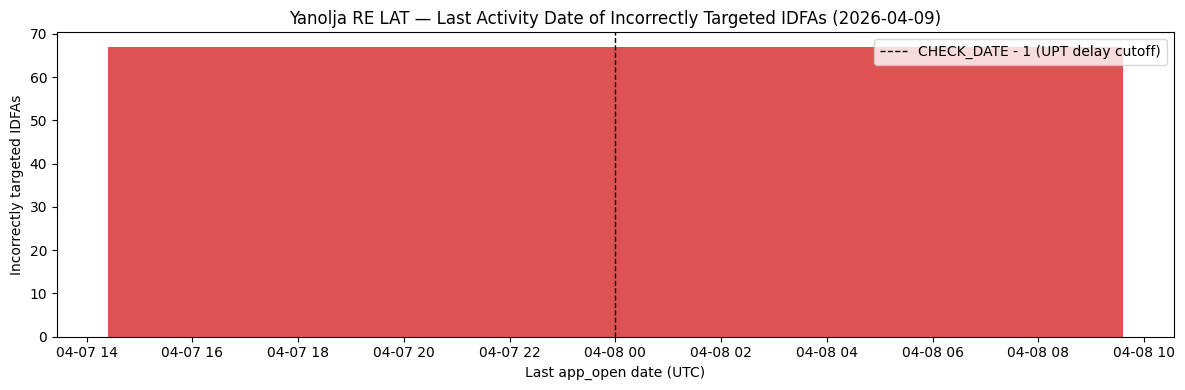

In [30]:
q_breakdown = """
WITH imp_idfas AS (
  SELECT DISTINCT req.device.ifa AS idfa
  FROM `focal-elf-631.prod_stream_view.imp`
  WHERE DATE(timestamp) = DATE('{check_date}')
    AND api.campaign.id = '{campaign_id}'
    AND req.device.ifa IS NOT NULL
    AND req.device.ifa != '00000000-0000-0000-0000-000000000000'
),
last_activity AS (
  SELECT s.maid AS idfa, MAX(s.date_utc) AS last_open_date
  FROM `focal-elf-631.rs.ios_re_closed_beta_summary_table` s
  INNER JOIN imp_idfas i ON SUBSTR(s.maid, 3) = i.idfa
  AND SUBSTR(s.maid, 1, 2) = 'i:'
  WHERE s.app_bundle IN ('{app_bundle}', '{app_bundle_num}')
    AND LOWER(s.event_name) = 'af_app_opened'
    AND s.date_utc >= DATE_SUB(DATE('{check_date}'), INTERVAL {excl_window} DAY)
    AND s.date_utc <  DATE('{check_date}')
  GROUP BY 1
)
SELECT
  last_open_date,
  COUNT(*) AS idfa_count
FROM last_activity
GROUP BY 1
ORDER BY 1
""".format(
    check_date=CHECK_DATE, excl_window=EXCL_WINDOW,
    campaign_id=CAMPAIGN_ID, app_bundle=APP_BUNDLE,
    app_bundle_num=APP_BUNDLE.lstrip('id')
)

df_breakdown = run_query(q_breakdown, 'Last activity date of incorrectly targeted IDFAs')
df_breakdown['last_open_date'] = pd.to_datetime(df_breakdown['last_open_date'])

# Chart
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_breakdown['last_open_date'], df_breakdown['idfa_count'], width=0.8, color='#d62728', alpha=0.8)
ax.axvline(pd.Timestamp(CHECK_DATE) - pd.Timedelta(days=1), color='black', linestyle='--',
           linewidth=1, label='CHECK_DATE - 1 (UPT delay cutoff)')
ax.set_xlabel('Last app_open date (UTC)')
ax.set_ylabel('Incorrectly targeted IDFAs')
ax.set_title(f'Yanolja RE LAT — Last Activity Date of Incorrectly Targeted IDFAs ({CHECK_DATE})')
ax.legend()
plt.tight_layout()
plt.savefig('incorrectly_targeted_by_last_activity.png', dpi=150)
plt.show()

In [32]:
df_breakdown

,last_open_date,idfa_count
0,2026-04-08,67


## Section 4 — Activity Date Distribution of Incorrectly Targeted Users (`postback.pb`)

Same breakdown as Section 3 but sourced from `postback.pb`.
Compare the two charts to see where the pipeline coverage gap falls across the activity window.

✅ Last activity date (postback.pb): 14 rows


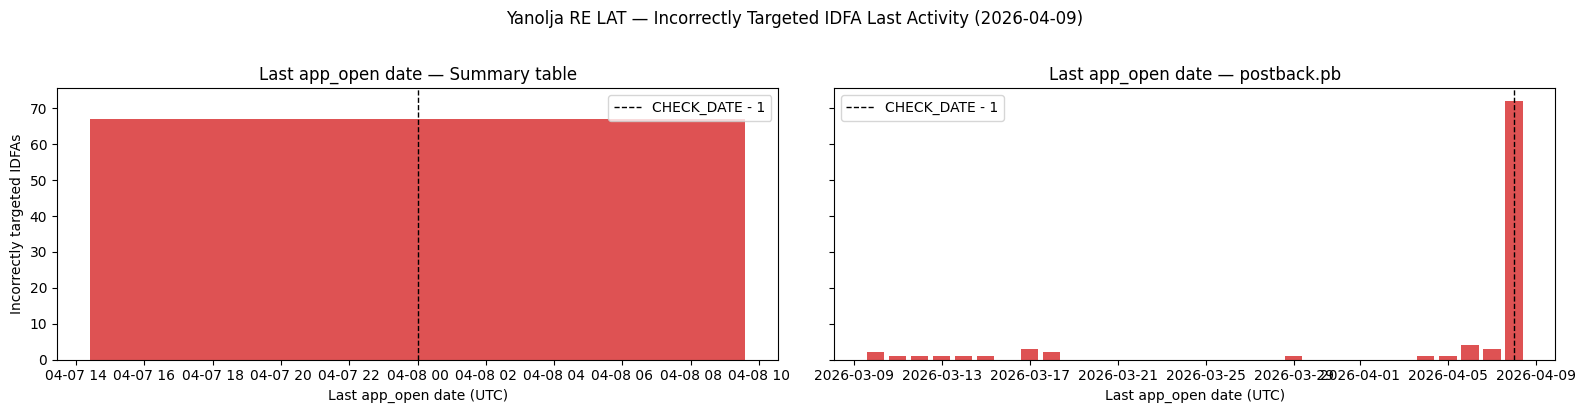

In [31]:
q_breakdown_pb = """
WITH imp_idfas AS (
  SELECT DISTINCT req.device.ifa AS idfa
  FROM `focal-elf-631.prod_stream_view.imp`
  WHERE DATE(timestamp) = DATE('{check_date}')
    AND api.campaign.id = '{campaign_id}'
    AND req.device.ifa IS NOT NULL
    AND req.device.ifa != '00000000-0000-0000-0000-000000000000'
),
last_activity AS (
  SELECT p.device.idfa AS idfa, MAX(DATE(p.timestamp)) AS last_open_date
  FROM `moloco-dsp-data-view.postback.pb` p
  INNER JOIN imp_idfas i ON p.device.idfa = i.idfa
  WHERE DATE(p.timestamp) >= DATE_SUB(DATE('{check_date}'), INTERVAL {excl_window} DAY)
    AND DATE(p.timestamp) <  DATE('{check_date}')
    AND p.app.bundle = '{app_bundle}'
    AND p.event.name = 'af_app_opened'
    AND p.device.idfa IS NOT NULL AND p.device.idfa != ''
  GROUP BY 1
)
SELECT last_open_date, COUNT(*) AS idfa_count
FROM last_activity
GROUP BY 1
ORDER BY 1
""".format(
    check_date=CHECK_DATE, excl_window=EXCL_WINDOW,
    campaign_id=CAMPAIGN_ID, app_bundle=APP_BUNDLE
)

df_breakdown_pb = run_query(q_breakdown_pb, 'Last activity date (postback.pb)')
df_breakdown_pb['last_open_date'] = pd.to_datetime(df_breakdown_pb['last_open_date'])

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, df, title in [
    (axes[0], df_breakdown,    'Summary table'),
    (axes[1], df_breakdown_pb, 'postback.pb'),
]:
    ax.bar(df['last_open_date'], df['idfa_count'], width=0.8, color='#d62728', alpha=0.8)
    ax.axvline(pd.Timestamp(CHECK_DATE) - pd.Timedelta(days=1),
             color='black', linestyle='--', linewidth=1, label='CHECK_DATE - 1')
    ax.set_title(f'Last app_open date — {title}')
    ax.set_xlabel('Last app_open date (UTC)')
    ax.legend()

axes[0].set_ylabel('Incorrectly targeted IDFAs')
plt.suptitle(
    f'Yanolja RE LAT — Incorrectly Targeted IDFA Last Activity ({CHECK_DATE})',
    y=1.02
)
plt.tight_layout()
plt.savefig('incorrectly_targeted_by_last_activity_comparison.png', dpi=150)
plt.show()

In [34]:
df_breakdown_pb

,last_open_date,idfa_count
0,2026-03-10,2
1,2026-03-11,1
2,2026-03-12,1
3,2026-03-13,1
4,2026-03-14,1
5,2026-03-15,1
6,2026-03-17,3
7,2026-03-18,2
8,2026-03-29,1
9,2026-04-04,1


## Section 5 — Deep Dive: 27 IDFAs in `postback.pb` but NOT in Summary Table

Identify the 27 IDFAs that appear as violations in `postback.pb` but are absent from
`ios_re_closed_beta_summary_table`, then investigate why:

- **Step 4a** — Isolate the 27 IDFAs
- **Step 4b** — Check if they exist in the summary table at all (any event, any bundle)
- **Step 4c** — Check their full event history in `postback.pb` (what events, what dates)

In [43]:
# Step 4a — Identify IDFAs in postback.pb but NOT in summary table
q_pb_only = """
WITH imp_idfas AS (
  SELECT DISTINCT req.device.ifa AS idfa
  FROM `focal-elf-631.prod_stream_view.imp`
  WHERE DATE(timestamp) = DATE('{check_date}')
    AND api.campaign.id = '{campaign_id}'
    AND req.device.ifa IS NOT NULL
    AND req.device.ifa != '00000000-0000-0000-0000-000000000000'
),
in_pb AS (
  SELECT DISTINCT p.device.idfa AS idfa
  FROM `moloco-dsp-data-view.postback.pb` p
  INNER JOIN imp_idfas i ON p.device.idfa = i.idfa
  WHERE DATE(p.timestamp) >= DATE_SUB(DATE('{check_date}'), INTERVAL {excl_window} DAY)
    AND DATE(p.timestamp) <  DATE('{check_date}')
    AND p.app.bundle = '{app_bundle}'
    AND p.event.name = 'af_app_opened'
    AND p.device.idfa IS NOT NULL AND p.device.idfa != ''
),
in_summary AS (
  SELECT DISTINCT SUBSTR(s.maid, 3) AS idfa
  FROM `focal-elf-631.rs.ios_re_closed_beta_summary_table` s
  INNER JOIN imp_idfas i ON SUBSTR(s.maid, 3) = i.idfa
  WHERE SUBSTR(s.maid, 1, 2) = 'i:'
    AND s.app_bundle IN ('{app_bundle}', '{app_bundle_num}')
    AND LOWER(s.event_name) = 'af_app_opened'
    AND s.date_utc >= DATE_SUB(DATE('{check_date}'), INTERVAL {excl_window} DAY)
    AND s.date_utc <  DATE('{check_date}')
)
SELECT pb.idfa
FROM in_pb pb
LEFT JOIN in_summary s USING (idfa)
WHERE s.idfa IS NULL
""".format(
    check_date=CHECK_DATE, excl_window=EXCL_WINDOW,
    campaign_id=CAMPAIGN_ID, app_bundle=APP_BUNDLE,
    app_bundle_num=APP_BUNDLE.lstrip('id')
)

df_pb_only = run_query(q_pb_only, 'IDFAs in PB but not summary table')
print(f'{len(df_pb_only)} IDFAs in postback.pb but missing from summary table')
df_pb_only.head()

✅ IDFAs in PB but not summary table: 27 rows
27 IDFAs in postback.pb but missing from summary table


,idfa
0,96b1c6bc-4a44-4a94-96d8-64424a49e638
1,a740794b-26d2-45e1-9bd2-22275675c734
2,bccb6aaa-e568-42dd-9499-f1105d5d9630
3,09654ac8-028a-4465-b058-d0c732b68586
4,f5afef69-c57a-41a6-a3b1-84e30743f125


In [44]:
# Step 4b — Are these 27 IDFAs present in the summary table at all?
idfa_list = ", ".join(f'"{x}"' for x in df_pb_only['idfa'].tolist())

q_summary_presence = f"""
SELECT
  SUBSTR(maid, 3)   AS idfa,
  MIN(date_utc)     AS earliest_date,
  MAX(date_utc)     AS latest_date,
  COUNT(DISTINCT event_name)   AS distinct_events,
  COUNT(DISTINCT app_bundle)   AS distinct_bundles,
  STRING_AGG(DISTINCT event_name ORDER BY event_name LIMIT 10) AS event_names,
  STRING_AGG(DISTINCT app_bundle ORDER BY app_bundle LIMIT 5)  AS app_bundles
FROM `focal-elf-631.rs.ios_re_closed_beta_summary_table`
WHERE SUBSTR(maid, 1, 2) = 'i:'
  AND SUBSTR(maid, 3) IN ({idfa_list})
  AND date_utc >= DATE_SUB(CURRENT_DATE(), INTERVAL 365 DAY)
GROUP BY 1
ORDER BY 1
"""

df_presence = run_query(q_summary_presence, 'Summary table presence (any event/bundle)')
print(f'{len(df_presence)} / {len(df_pb_only)} IDFAs found in summary table (any event/bundle)')
df_presence

✅ Summary table presence (any event/bundle): 27 rows
27 / 27 IDFAs found in summary table (any event/bundle)


,idfa,earliest_date,latest_date,distinct_events,distinct_bundles,event_names,app_bundles
0,07060291-c8a5-41a1-bd62-0ac92da202ab,2025-04-17,2026-04-09,29,6,"ADD_TO_CART,OPEN,PURCHASE,VIEW_ITEM,VIEW_ITEMS...","1441742921,1579464667,com.coupang.coupang-eats..."
1,09654ac8-028a-4465-b058-d0c732b68586,2026-01-05,2026-04-09,30,7,"ADD_TO_CART,OPEN,PURCHASE,VIEW_ITEM,VIEW_ITEMS...","1441742921,1579464667,com.coupang.coupang-eats..."
2,16ff0f0d-5326-471e-ae20-627a8569c899,2025-05-31,2026-04-09,56,7,"ads_income_fuzz_cv,ads_income_p4p_total_fuzz,a...","1441742921,848091833,com.emart.ssg,id101876999..."
3,1b546b4b-3147-4496-8f37-98fbb34dad31,2025-04-10,2026-04-09,55,7,"01_App Launch,02_Download Complete,03_NPSN,04_...","1441742921,1579464667,com.coupang.coupang-eats..."
4,2af8c74c-7c77-448f-aef2-ae57e9796648,2025-09-20,2026-04-09,38,8,"ADD_TO_CART,LOGIN,OPEN,OPT_IN,PURCHASE,VIEW_IT...","1441742921,1579464667,848091833,com.coupang.co..."
5,2b6f6ebf-98af-4986-93b7-a41378305890,2025-04-10,2026-04-08,24,7,"ADD_TO_CART,OPEN,PURCHASE,VIEW_ITEM,VIEW_ITEMS...","1441742921,1579464667,com.coupang.coupang-eats..."
6,33363cc0-5197-47dc-8d44-25c9ea9bc674,2025-04-10,2026-04-09,69,8,"01_App Launch,INSTALL,OPEN,OPT_IN,VIEW_ITEMS,a...","1441742921,1579464667,com.coupang.coupang-eats..."
7,35e20525-f2d2-403e-b215-f2ced98e9f65,2025-04-10,2026-04-09,43,7,"ADD_TO_CART,OPEN,PURCHASE,VIEW_ITEM,VIEW_ITEMS...","1441742921,1579464667,com.coupang.coupang-eats..."
8,42e4d97b-4351-4cb2-b073-64c664debd50,2025-04-11,2026-04-09,29,3,"ads_income_fuzz_cv,af_app_opened,af_content_vi...","id1018769995,id436672029,id436731843"
9,475e5b4b-6f27-491b-a220-ec0d3ac99fb9,2025-04-12,2026-04-09,28,4,"ADD_TO_CART,LOGIN,OPEN,PURCHASE,PURCHASE_CANCE...","com.coupang.coupang-eats,id1018769995,id148215..."


In [45]:
# Step 4c — Full event history in postback.pb for the 27 IDFAs
q_pb_history = f"""
SELECT
  device.idfa,
  DATE(timestamp)   AS event_date,
  event.name        AS event_name,
  COUNT(*)          AS event_count
FROM `moloco-dsp-data-view.postback.pb`
WHERE DATE(timestamp) >= DATE_SUB(DATE('{CHECK_DATE}'), INTERVAL {EXCL_WINDOW} DAY)
  AND DATE(timestamp) <  DATE('{CHECK_DATE}')
  AND app.bundle = '{APP_BUNDLE}'
  AND device.idfa IN ({idfa_list})
  AND device.idfa IS NOT NULL
GROUP BY 1, 2, 3
ORDER BY 1, 2
"""

df_pb_history = run_query(q_pb_history, 'PB event history for 27 IDFAs')
df_pb_history

✅ PB event history for 27 IDFAs: 79 rows


,idfa,event_date,event_name,event_count
0,07060291-c8a5-41a1-bd62-0ac92da202ab,2026-03-14,af_content_view,2
1,07060291-c8a5-41a1-bd62-0ac92da202ab,2026-03-14,af_app_opened,2
2,07060291-c8a5-41a1-bd62-0ac92da202ab,2026-03-14,af_purchase,1
3,07060291-c8a5-41a1-bd62-0ac92da202ab,2026-04-07,reengagement,1
4,09654ac8-028a-4465-b058-d0c732b68586,2026-03-11,af_app_opened,1
...,...,...,...,...
74,ee28460b-2de4-4c9a-ae5d-94dd90a965ef,2026-03-10,af_app_opened,1
75,f5afef69-c57a-41a6-a3b1-84e30743f125,2026-04-05,af_content_view,1
76,f5afef69-c57a-41a6-a3b1-84e30743f125,2026-04-05,content_view_ho_d,1
77,f5afef69-c57a-41a6-a3b1-84e30743f125,2026-04-06,reengagement,1


## Section 6 — Methodology Assessment

| Dimension | Assessment |
|-----------|------------|
| Imp anchor | ✅ Using CHECK_DATE impressions (not L30d) — focuses on users actually served ads |
| Activity source | ✅ `ios_re_closed_beta_summary_table` — same source as customer set seed SQL |
| UPT delay handling | ✅ CHECK_DATE excluded from activity window — avoids false positives from same-day opens |
| Attribution scope | ✅ Both tables capture all events (attributed + unattributed); difference reflects pipeline coverage |
| Limitation | ⚠️ CHECK_DATE must match a day with campaign impressions — validate `total_imp_idfas > 0` |